# 01 · Calidad de los datos

**Pregunta:** ¿qué tan completos y confiables son los datos que reportan los sensores, y qué
problemas hay que resolver antes de entrenar un modelo?

Los datos son las lecturas de los 21 sensores de la red, cada 15 min, del 2025-01-01 al
2026-12-31. Cada sensor mide cloro residual libre (`CL2`), temperatura (`TEMP`),
turbidez (`TURB`), pH (`PH`) y presión (`P`). Como en cualquier red de sensores, las lecturas
traen imperfecciones:

- **ruido de medición** y **deriva** entre calibraciones (cada 30 días);
- **cortes de comunicación**: el equipo completo de un nodo deja de reportar entre 15 min y 2 h;
- **fallas del sensor**: valor *pegado*, *deriva* fuerte, *picos*, *ruido* excesivo o dato *faltante*.

Junto con las lecturas hay dos fuentes de información adicional: las columnas `falla_*`
(qué falla tenía cada sensor en cada momento) y la tabla `verdad_*` (el **valor de referencia**
de cada parámetro, sin ruido ni fallas del instrumento). Aquí se usan para **medir** la calidad
de los datos; el modelo no las recibe como entrada, porque en operación no están disponibles al
momento de pronosticar.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # para poder importar src/ desde notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src import carga
from src.graficos import estilo, guardar, COLORES, GRIS

estilo()
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)

t = carga.cargar_todo()                  # lo que reportan los sensores (+ etiquetas)
v = carga.cargar_todo(verdad=True)       # valor de referencia (sin ruido ni fallas)
S = carga.sensores(t)
CALIDAD = ["CL2", "TEMP", "TURB", "PH"]          # parámetros con fallas de sensor
FALLAS = {1: "pegado", 2: "deriva", 3: "picos", 4: "ruido", 5: "faltante"}
print(f"{len(t):,} lecturas × {t.shape[1]} columnas · {len(S)} sensores")
print(f"Periodo: {t.index[0]} → {t.index[-1]}")

70,077 lecturas × 215 columnas · 21 sensores
Periodo: 2025-01-01 00:00:00 → 2026-12-31 23:00:00


## 1. Panorama general

Primero, la estructura: cuántas lecturas tiene cada partición y si el índice de tiempo es
regular (una lectura exacta cada 15 min, sin saltos ni duplicados).

In [2]:
resumen = []
for p in carga.PARTICIONES:
    i = t.index[t.particion == p]
    esperado = pd.date_range(i[0], i[-1], freq="15min")
    resumen.append({"partición": p, "desde": i[0], "hasta": i[-1], "lecturas": len(i),
                    "días": round(len(i) / 96, 1), "saltos": len(esperado.difference(i)),
                    "duplicados": int(i.duplicated().sum())})
pd.DataFrame(resumen).set_index("partición")

,desde,hasta,lecturas,días,saltos,duplicados
partición,,,,,,
entrenamiento,2025-01-01,2026-04-30 23:45:00,46560,485.0,0,0
validacion,2026-05-01,2026-08-31 23:45:00,11808,123.0,0,0
prueba,2026-09-01,2026-12-31 23:00:00,11709,122.0,0,0


In [3]:
tipos = {"lecturas de sensores (CL2, TEMP, TURB, PH, P)": sum(len(carga.columnas(t, p)) for p in carga.PARAMETROS),
         "caudal de la fuente y lluvia": 2,
         "etiquetas de falla de sensor (falla_*)": len([c for c in t if c.startswith("falla_")]),
         "etiquetas de evento (evento_*)": len([c for c in t if c.startswith("evento_")])}
pd.Series(tipos, name="columnas").to_frame()

,columnas
"lecturas de sensores (CL2, TEMP, TURB, PH, P)",105
caudal de la fuente y lluvia,2
etiquetas de falla de sensor (falla_*),84
etiquetas de evento (evento_*),23


El índice es regular en las tres particiones: sin saltos ni duplicados. La prueba termina el
31/12/2026 a las 23:00 (faltan las tres últimas lecturas del año, sin efecto práctico).

## 2. Datos faltantes

Un dato faltante puede venir de dos causas distintas, y conviene separarlas porque se tratan
diferente:

- **corte de comunicación**: el nodo completo deja de reportar (los 5 parámetros a la vez);
- **sensor faltante**: un solo parámetro deja de llegar mientras los demás del nodo siguen bien.

In [4]:
faltan = pd.DataFrame({p: t[[f"{p}_{n}" for n in S]].isna().mean().values * 100 for p in carga.PARAMETROS}, index=S)

corte = pd.DataFrame({n: t[[f"{p}_{n}" for p in carga.PARAMETROS]].isna().all(axis=1) for n in S})
solo_param = {p: (t[carga.columnas(t, p)].isna().values & ~corte.values).mean() * 100 for p in CALIDAD}

print(f"Datos faltantes en total: {t[[c for p in carga.PARAMETROS for c in carga.columnas(t, p)]].isna().values.mean()*100:.2f} %")
print(f"  por cortes de comunicación (nodo completo): {corte.values.mean()*100:.2f} % de las lecturas")
print(f"  por sensor faltante (un solo parámetro):    " +
      ", ".join(f"{p} {x:.3f} %" for p, x in solo_param.items()))
print(f"Instantes con al menos un nodo en corte: {corte.any(axis=1).mean()*100:.1f} %")
print(f"Caudal y lluvia faltantes: {t['Q_R1'].isna().sum()} y {t['lluvia_mm_h'].isna().sum()}")

Datos faltantes en total: 0.61 %
  por cortes de comunicación (nodo completo): 0.61 % de las lecturas
  por sensor faltante (un solo parámetro):    CL2 0.016 %, TEMP 0.012 %, TURB 0.005 %, PH 0.005 %
Instantes con al menos un nodo en corte: 12.0 %
Caudal y lluvia faltantes: 0 y 0


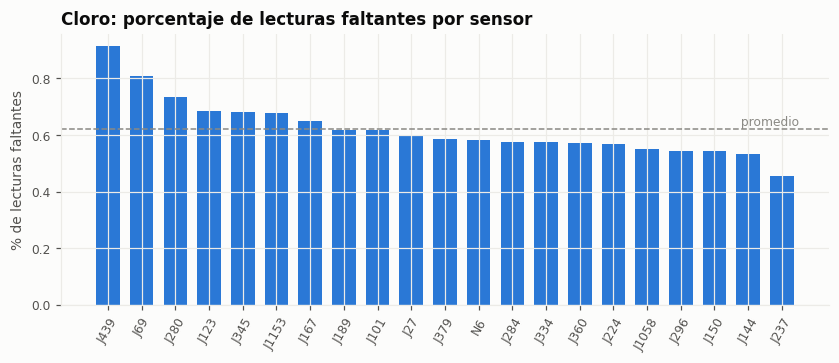

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.2))
orden = faltan["CL2"].sort_values(ascending=False).index
ax.bar(orden, faltan.loc[orden, "CL2"], color=COLORES[0], width=0.7)
ax.axhline(faltan["CL2"].mean(), color=GRIS, ls="--", lw=1)
ax.text(len(orden) - 0.5, faltan["CL2"].mean(), " promedio", va="bottom", ha="right", color=GRIS, fontsize=8)
ax.set_ylabel("% de lecturas faltantes")
ax.set_title("Cloro: porcentaje de lecturas faltantes por sensor")
ax.tick_params(axis="x", rotation=60)
guardar(fig, "01_faltantes_por_sensor"); plt.show()

Los faltantes están repartidos de forma pareja entre sensores (todos por debajo de 1 %): no hay
un sensor problemático que convenga descartar. Lo que importa más para el modelo es **cuánto
duran los huecos**, porque eso decide si basta con rellenar o hay que tratar el hueco como
información ausente.

In [6]:
def tramos(b):
    # duración (en lecturas de 15 min) de cada tramo continuo en True
    b = np.r_[False, np.asarray(b), False].astype(int)
    d = np.diff(b)
    return np.where(d == -1)[0] - np.where(d == 1)[0]

dur_corte = np.concatenate([tramos(corte[n]) for n in S]) * 15
dur_param = np.concatenate([tramos(t[f"{p}_{n}"].isna() & ~corte[n]) for n in S for p in CALIDAD]) * 15
tabla = pd.DataFrame({
    "tramos": [len(dur_corte), len(dur_param)],
    "mediana (min)": [np.median(dur_corte), np.median(dur_param) if len(dur_param) else np.nan],
    "p90 (min)": [np.percentile(dur_corte, 90), np.percentile(dur_param, 90) if len(dur_param) else np.nan],
    "máximo (min)": [dur_corte.max(), dur_param.max() if len(dur_param) else np.nan],
}, index=["corte de comunicación", "sensor faltante"])
tabla

,tramos,mediana (min),p90 (min),máximo (min)
corte de comunicación,1981,60.0,120.0,225
sensor faltante,13,720.0,1224.0,1380


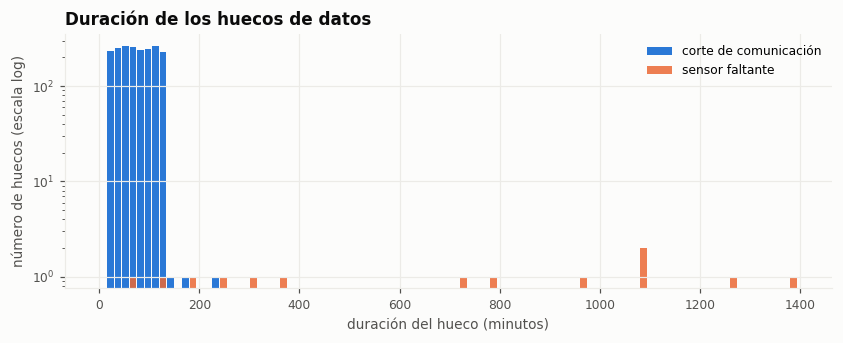

In [7]:
fig, ax = plt.subplots(figsize=(9, 3))
bins = np.arange(0, max(dur_corte.max(), dur_param.max() if len(dur_param) else 0) + 30, 15)
ax.hist(dur_corte, bins=bins, color=COLORES[0], label="corte de comunicación", rwidth=0.9)
ax.hist(dur_param, bins=bins, color=COLORES[1], label="sensor faltante", rwidth=0.9, alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("duración del hueco (minutos)"); ax.set_ylabel("número de huecos (escala log)")
ax.set_title("Duración de los huecos de datos")
ax.legend()
guardar(fig, "01_duracion_huecos"); plt.show()

## 3. Fallas de sensor

Además de los faltantes, hay lecturas que **sí llegan pero están mal**. Son las más peligrosas
para un modelo, porque no se ven como un hueco. El catálogo de fallas dice cuáles
son, cuándo ocurrieron y cuánto duraron.

In [8]:
cat = carga.catalogo_fallas()
F = t[[f"falla_{p}_{n}" for n in S for p in CALIDAD]]
lecturas_por_tipo = pd.Series(F.values.ravel()).map(FALLAS).value_counts()

res = cat.groupby("tipo").agg(fallas=("id", "count"), duración_mediana_h=("duracion_h", "median"),
                              duración_máx_h=("duracion_h", "max"))
res["lecturas afectadas"] = lecturas_por_tipo.reindex(res.index).fillna(0).astype(int)
res["% de las lecturas"] = res["lecturas afectadas"] / F.size * 100
res.loc["faltante", "nota"] = "incluye los cortes de comunicación"
res.sort_values("lecturas afectadas", ascending=False)

,fallas,duración_mediana_h,duración_máx_h,lecturas afectadas,% de las lecturas,nota
tipo,,,,,,
faltante,13,12.0,23,36220,0.615,incluye los cortes de comunicación
deriva,13,95.0,165,5209,0.088,NaN
pegado,11,23.0,38,977,0.017,NaN
ruido,9,15.0,23,520,0.009,NaN
picos,15,5.0,11,324,0.006,NaN


In [9]:
print("Fallas por parámetro:", cat.parametro.value_counts().to_dict())
print("Sensores con más fallas:", cat.nodo.value_counts().head(5).to_dict())

Fallas por parámetro: {'CL2': 21, 'TURB': 16, 'PH': 12, 'TEMP': 12}
Sensores con más fallas: {'J280': 7, 'J284': 6, 'J69': 5, 'J189': 5, 'J439': 5}


Para ver cómo luce cada tipo de falla, se compara la lectura del sensor con el valor de referencia en un
ejemplo de cada una.

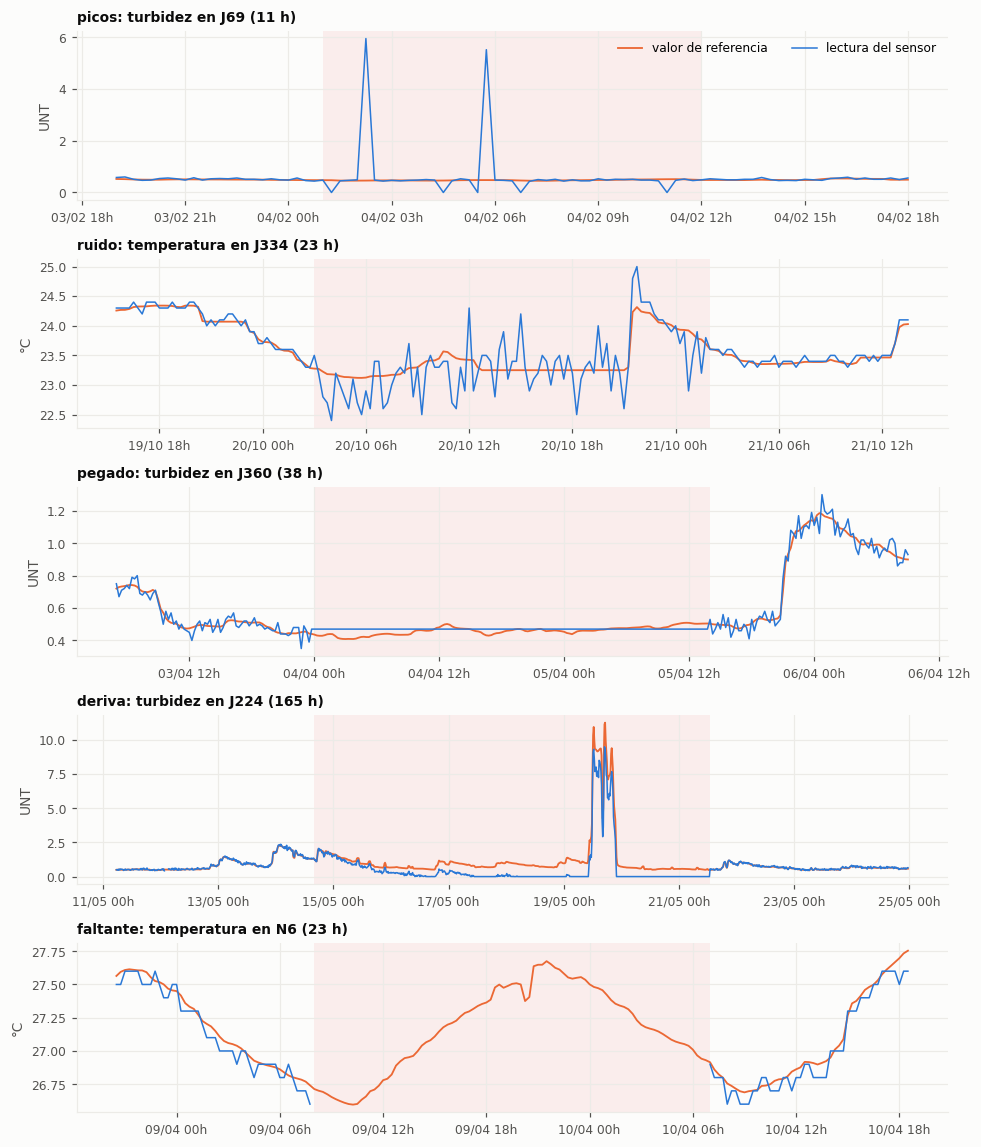

In [10]:
ejemplos = cat[cat.tipo != "faltante"].sort_values("duracion_h").groupby("tipo").nth(-1)
ejemplos = pd.concat([ejemplos, cat[cat.tipo == "faltante"].iloc[[0]]])
fig, axes = plt.subplots(len(ejemplos), 1, figsize=(9, 2.1 * len(ejemplos)))
for ax, (_, f) in zip(axes, ejemplos.iterrows()):
    col = f"{f.parametro}_{f.nodo}"
    margen = pd.Timedelta(hours=max(6, f.duracion_h * 0.5))
    tramo = slice(f.inicio - margen, f.fin + margen)
    ax.axvspan(f.inicio, f.fin, color=COLORES[7], alpha=0.08, lw=0)
    ax.plot(v.loc[tramo, col], color=COLORES[1], lw=1.2, label="valor de referencia")
    ax.plot(t.loc[tramo, col], color=COLORES[0], lw=1, label="lectura del sensor")
    ax.set_title(f"{f.tipo}: {carga.NOMBRES_PARAMETRO[f.parametro].lower()} en {f.nodo} ({f.duracion_h} h)", fontsize=9)
    ax.set_ylabel(carga.UNIDADES[f.parametro] or f.parametro)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
axes[0].legend(loc="upper right", ncol=2)
fig.tight_layout()
guardar(fig, "01_ejemplos_fallas"); plt.show()

## 4. Ruido de medición

Fuera de las fallas, la lectura difiere del valor de referencia solo por el ruido del instrumento y la
deriva lenta entre calibraciones. Se mide ese error en todas las lecturas sin falla y se compara
con la especificación del sensor.

In [11]:
meta = carga.metadatos()["modelo_sensor"]
filas = {}
for p in carga.PARAMETROS:
    err = []
    for n in S:
        o, r = t[f"{p}_{n}"], v[f"{p}_{n}"]
        ok = o.notna() if p == "P" else (t[f"falla_{p}_{n}"] == 0) & o.notna()
        err.append((o - r)[ok])
    e = pd.concat(err)
    filas[p] = {"unidad": carga.UNIDADES[p] or "-", "sesgo medio": e.mean(), "desv. estándar": e.std(),
                "p99 |error|": e.abs().quantile(0.99), "ruido base (especificación)": meta[p]["ruido"],
                "resolución": meta[p]["resol"]}
ruido = pd.DataFrame(filas).T
ruido

,unidad,sesgo medio,desv. estándar,p99 |error|,ruido base (especificación),resolución
CL2,mg/L,-0.001,0.044,0.123,0.02,0.01
TEMP,°C,0.002,0.081,0.226,0.05,0.1
TURB,UNT,0.001,0.064,0.173,0.02,0.01
PH,-,0.001,0.035,0.104,0.02,0.01
P,m,0.0,0.202,0.522,0.2,0.1


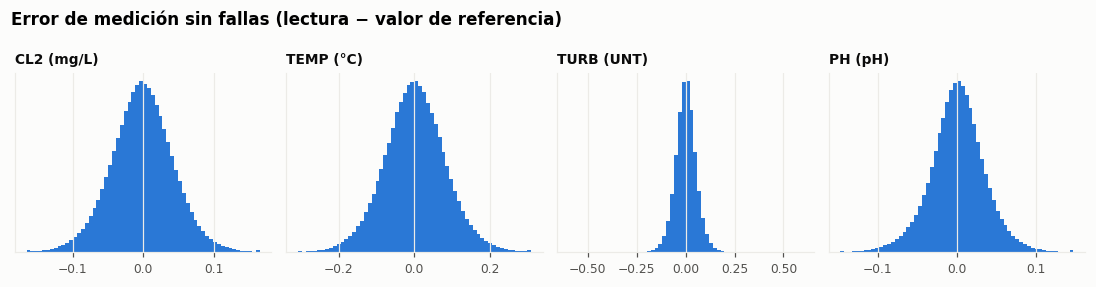

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2.6))
for ax, p in zip(axes, CALIDAD):
    e = pd.concat([(t[f"{p}_{n}"] - v[f"{p}_{n}"])[(t[f"falla_{p}_{n}"] == 0)] for n in S]).dropna()
    lim = e.abs().quantile(0.999)
    ax.hist(e.clip(-lim, lim), bins=60, color=COLORES[0])
    ax.set_title(f"{p} ({carga.UNIDADES[p] or 'pH'})", fontsize=9)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
fig.suptitle("Error de medición sin fallas (lectura − valor de referencia)", x=0.01, ha="left", fontsize=11, fontweight="bold")
fig.tight_layout()
guardar(fig, "01_ruido_medicion"); plt.show()

## 5. Valores fuera de rango o imposibles

Se revisa el mínimo y el máximo de cada parámetro, cuántas lecturas quedan exactamente en el
límite inferior del sensor (0) y cuántas caen fuera de lo que es físicamente razonable en una red
de agua potable.

In [13]:
razonable = {"CL2": (0, 5), "TEMP": (15, 35), "TURB": (0, 100), "PH": (5, 10), "P": (0, 150)}
filas = {}
for p in carga.PARAMETROS:
    x = t[carga.columnas(t, p)].values
    r = v[carga.columnas(v, p)].values
    lo, hi = razonable[p]
    filas[p] = {"mínimo": np.nanmin(x), "máximo": np.nanmax(x),
                "lecturas = 0": int((x == 0).sum()),
                f"fuera de rango razonable": int(((x < lo) | (x > hi)).sum()),
                "referencia fuera de rango": int(((r < lo) | (r > hi)).sum())}
rangos = pd.DataFrame(filas).T
rangos.insert(2, "rango razonable", [f"{a}–{b}" for a, b in razonable.values()])
rangos

,mínimo,máximo,rango razonable,lecturas = 0,fuera de rango razonable,referencia fuera de rango
CL2,0.0,1.79,0–5,2185.0,0.0,0.0
TEMP,0.0,30.40,15–35,3.0,4.0,4.0
TURB,0.0,21.53,0–100,1091.0,0.0,0.0
PH,0.0,8.85,5–10,1.0,4.0,4.0
P,-0.1,110.40,0–150,4.0,1.0,4.0


Hay dos casos distintos aquí:

1. **Cloro en 0**: el sensor no puede reportar negativos, así que cuando el cloro es muy bajo
   (durante una falla de cloración) el ruido empuja algunas lecturas a 0. Es el comportamiento
   normal de un sensor, no un error.
2. **Temperatura y pH en 0**: eso es imposible físicamente. Se revisa a continuación.

In [14]:
imposible = pd.DataFrame({n: (t[f"TEMP_{n}"] < 15) | (t[f"PH_{n}"] < 5) for n in S})
casos = imposible.stack()
casos = casos[casos]
for (fecha, n), _ in casos.items():
    print(fecha, n, "TEMP", t.at[fecha, f"TEMP_{n}"], "PH", t.at[fecha, f"PH_{n}"],
          "TURB", t.at[fecha, f"TURB_{n}"], "| presión", t.at[fecha, f"P_{n}"], "m",
          "| referencia TEMP", round(float(v.at[fecha, f"TEMP_{n}"]), 2))

2026-03-01 22:15:00 J334 TEMP 0.0 PH 0.01 TURB 0.02 | presión 0.1 m | referencia TEMP 0.0
2026-03-01 22:30:00 J334 TEMP 0.0 PH 0.0 TURB 0.0 | presión 0.2 m | referencia TEMP 0.0
2026-03-01 22:45:00 J334 TEMP 0.1 PH 0.02 TURB 0.0 | presión 0.2 m | referencia TEMP 0.0
2026-03-01 23:00:00 J334 TEMP 0.0 PH 0.01 TURB 0.0 | presión 2.8 m | referencia TEMP 0.0


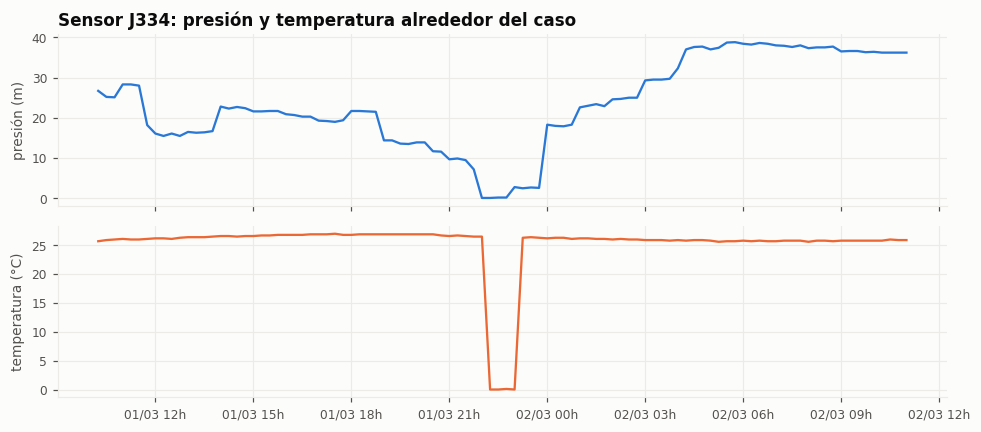

In [15]:
if len(casos):
    n = casos.index[0][1]
    tramo = slice(casos.index[0][0] - pd.Timedelta(hours=12), casos.index[-1][0] + pd.Timedelta(hours=12))
    fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
    axes[0].plot(t.loc[tramo, f"P_{n}"], color=COLORES[0])
    axes[0].set_ylabel("presión (m)"); axes[0].set_title(f"Sensor {n}: presión y temperatura alrededor del caso")
    axes[1].plot(t.loc[tramo, f"TEMP_{n}"], color=COLORES[1])
    axes[1].set_ylabel("temperatura (°C)")
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
    fig.tight_layout(); guardar(fig, "01_presion_cero"); plt.show()

## 6. ¿Se pueden detectar las fallas sin etiquetas?

En operación las columnas `falla_*` no están disponibles en el momento. Antes de modelar conviene saber qué fallas
se pueden marcar con reglas simples, solo mirando la serie de cada sensor:

- **pegado**: el valor no cambia nada durante 4 h (16 lecturas seguidas iguales). Un sensor que funciona
  siempre tiene algo de ruido, así que una serie plana es sospechosa. Se excluyen los ceros, que
  son el límite inferior del sensor y no una falla.
- **pico**: una lectura que se aleja de sus dos vecinas (la anterior y la siguiente) más que un
  umbral, mientras las vecinas están cerca entre sí. Usa la lectura siguiente, así que marca el
  pico con 15 min de retraso. Umbrales: cloro 0,3 mg/L, turbidez 2 UNT, pH 0,4 y temperatura 1,5 °C.

Para cada regla se mide qué parte de las lecturas con esa falla marca (*recall*) y qué parte de lo
que marca es realmente esa falla (*precisión*). En una falla de picos solo algunas lecturas de la
ventana tienen pico, así que ahí se cuentan solo las lecturas que de verdad se alejan del valor
de referencia.

In [16]:
UMBRAL_PICO = {"CL2": 0.3, "TURB": 2.0, "PH": 0.4, "TEMP": 1.5}

def pegado(x, p, lecturas=16):
    sin_cambio = (x.diff() == 0).astype(int).rolling(lecturas - 1).sum() == lecturas - 1
    return sin_cambio & (x > 0)

def pico(x, p):
    antes, despues = x.shift(1), x.shift(-1)
    return ((x - (antes + despues) / 2).abs() > UMBRAL_PICO[p]) & ((antes - despues).abs() < UMBRAL_PICO[p] / 2)

def evaluar(regla, codigo, solo_alteradas=False):
    filas = {}
    for p in CALIDAD:
        marcadas = reales = aciertos = 0
        for n in S:
            x = t[f"{p}_{n}"]
            m = regla(x, p).fillna(False).values
            f = (t[f"falla_{p}_{n}"] == codigo).to_numpy(copy=True)
            if solo_alteradas:
                f &= ((x - v[f"{p}_{n}"]).abs() > UMBRAL_PICO[p] / 2).values
            marcadas += m.sum(); reales += f.sum(); aciertos += (m & f).sum()
        filas[p] = {"lecturas con la falla": reales, "marcadas": marcadas, "aciertos": aciertos}
    d = pd.DataFrame(filas).T
    d.loc["total"] = d.sum()
    d["recall %"] = 100 * d["aciertos"] / d["lecturas con la falla"].clip(lower=1)
    d["precisión %"] = 100 * d["aciertos"] / d["marcadas"].clip(lower=1)
    return d

print("Regla de sensor pegado (4 h sin cambio):")
display(evaluar(pegado, 1))
print("Regla de picos:")
display(evaluar(pico, 3, solo_alteradas=True))

Regla de sensor pegado (4 h sin cambio):


,lecturas con la falla,marcadas,aciertos,recall %,precisión %
CL2,240,212,212,88.333,100.000
TEMP,187,179,142,75.936,79.330
TURB,364,308,308,84.615,100.000
PH,186,143,143,76.882,100.000
total,977,842,805,82.395,95.606


Regla de picos:


,lecturas con la falla,marcadas,aciertos,recall %,precisión %
CL2,10,29,6,60.000,20.690
TEMP,17,9,9,52.941,100.000
TURB,8,27,6,75.000,22.222
PH,8,18,8,100.000,44.444
total,43,83,29,67.442,34.940


La deriva y el ruido excesivo no se pueden separar de un cambio real con una regla tan simple:
para eso hay que comparar contra otros sensores de la red o contra un pronóstico, que es parte del
trabajo de los modelos.

## 7. Conclusiones e implicaciones para el modelo

**Lo que dicen los datos**

1. **La estructura está limpia.** 70 077 lecturas cada 15 min, sin saltos ni duplicados, en las
   tres particiones (entrenamiento 16 meses, validación 4, prueba 4).
2. **Faltan pocos datos (0,61 %), pero faltan seguido.** Casi todo viene de cortes de
   comunicación: 1 981 cortes cortos (mediana 1 h, máximo 3 h 45 min) que apagan el nodo completo.
   En el **12 % de los instantes hay al menos un sensor sin reportar**, así que el modelo va a ver
   entradas incompletas todo el tiempo y tiene que tolerarlas. Aparte hay 13 episodios de un solo
   parámetro faltante, mucho más largos (mediana 12 h, hasta 23 h).
3. **Las fallas que no dejan hueco son pocas, pero existen.** Deriva fuerte (0,09 % de las
   lecturas), sensor pegado (0,02 %), ruido excesivo y picos (menos de 0,01 % cada una). Son las más
   peligrosas porque la lectura llega y parece válida.
4. **El ruido del instrumento pone un piso al error.** Sin fallas, la lectura difiere del valor de referencia
   con una desviación de 0,044 mg/L en cloro, 0,06 UNT en turbidez, 0,035 en pH y 0,08 °C en
   temperatura (ruido base, más una parte proporcional al valor, más la deriva entre calibraciones).
   Ningún pronóstico puede acercarse a la lectura observada mucho más que eso. Sirve para fijar la
   tolerancia de la meta del 80 %: por ejemplo, ±0,1 mg/L en cloro equivale a unas 2,3 veces ese
   ruido.
5. **Hay ceros que no son ceros.** El sensor no reporta valores negativos: 2 185 lecturas de cloro
   quedan en 0 durante fallas de cloración (el valor de referencia es bajo, pero no cero) y 1 091 de turbidez
   quedan en 0 por fallas de deriva negativa. Son datos *censurados*: el valor de referencia está por debajo
   del límite del sensor.
6. **Hay lecturas inválidas por falta de presión.** El 01/03/2026 entre las 22:15 y las 23:00, el
   nodo J334 se queda sin presión (0,1–0,2 m) y reporta temperatura, pH y turbidez en 0. Son
   valores imposibles: con la tubería vacía el sensor no está midiendo agua. Son solo 4 lecturas,
   pero muestran que hay que validar las lecturas de calidad contra la presión.
7. **Algunas fallas se detectan con reglas simples.** La regla de sensor pegado (4 h sin cambio)
   encuentra el 82 % de esas lecturas con 96 % de precisión. La de picos encuentra el 67 %, pero con
   35 % de precisión: la mayoría de sus "falsas alarmas" son lecturas con ruido excesivo (que
   también son una falla) y **cambios reales y rápidos de turbidez durante los eventos**, que no se
   deben borrar.

**Qué implica para el modelo**

- **Capa de calidad de datos antes del modelo:**
  - marcar como faltante lo que la regla de pegado detecte;
  - aplicar la regla de picos solo a cloro, pH y temperatura, no a turbidez.
- **Relleno de huecos con límite:**
  - interpolar huecos de hasta unas 4 h, que cubren todos los cortes de comunicación;
  - dejar como faltante lo más largo;
  - darle al modelo una columna que indique qué datos fueron rellenados, para que sepa cuándo
    confiar menos.
- **Evaluar contra la lectura y contra el valor de referencia.** El valor de referencia (`verdad_*`) dice qué tan bien
  el modelo entiende la red. La lectura dice qué vería un operador. La diferencia entre ambas es el
  ruido del punto 4.
- **Validar contra la presión:** cuando un nodo se queda sin presión (por ejemplo, menos de 1 m),
  sus lecturas de calidad se tratan como faltantes.